### `PromptTemplate`으로 프롬프트 템플릿화

질문 문장을 매번 파이썬 문자열 포매팅(f-string)으로 직접 만드는 대신,
`PromptTemplate`을 쓰면 **`{변수}`** 자리표시자를 채워 넣는 방식으로
프롬프트를 재사용 가능한 "템플릿"으로 만들 수 있다.

강의 자료나 서비스 코드에서 **여러 개의 유사한 질문을 자동으로 생성**할 때
특히 유용하다.

---

In [1]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

In [ ]:
from langchain_core.prompts import PromptTemplate

llm_openai = ChatOpenAI(model="gpt-4o-mini")
word_template = PromptTemplate.from_template(
    "다음 단어의 뜻을 초등학생도 이해할 수 있게 2~3문장으로 설명해줘: {word}"
)

prompt = word_template.invoke({"word": "재귀함수"}) #invoke() 메서드로 프롬프트를 실행하고 결과를 반환
response = llm_openai.invoke(prompt)
print(response.content)

재귀함수는 자신을 다시 부르는 함수를 말해. 마치 거울을 보고 또 거울을 보는 것처럼, 함수가 스스로를 호출해서 문제를 해결해 나가는 거야. 예를 들어, 숫자를 세는 것 같은 간단한 작업을 반복할 때 재귀함수를 사용할 수 있어.


In [4]:
llm_exaone = ChatOllama(model="exaone3.5")
prompt = word_template.invoke({"word": "재귀함수"})  # 템플릿은 모델과 무관하게 재사용
response = llm_exaone.invoke(prompt)
print(response.content)

재귀함수는 컴퓨터가 자기 자신을 다시 부르면서 문제를 해결하는 특별한 방법이야. 마치 거울 속 거울 속 거울처럼 계속 스스로를 찾아가는 것처럼, 작은 문제부터 해결해 나가다가 결국 큰 문제까지 해결하는 거지. 이렇게 하면 복잡한 일도 단계별로 쉽게 처리할 수 있어!


### `ChatPromptTemplate` (system + human 템플릿)

`PromptTemplate`이 문자열 하나짜리 템플릿이라면, `ChatPromptTemplate`은\
system/human 등 **여러 역할의 메시지를 한 번에 템플릿화**할 수 있다.\
`{role}`, `{question}`처럼 여러 자리표시자를 동시에 채울 수 있어서\
실무 프롬프트 관리에 훨씬 자주 쓰인다.

In [5]:
from langchain_core.prompts import ChatPromptTemplate

qa_template = ChatPromptTemplate.from_messages([
    ("system", "너는 {role} 분야 전문가야. 답변은 한국어로, 3줄 이내로 핵심만 말해줘."),
    ("human", "{question}"),
])

prompt = qa_template.invoke({"role": "데이터베이스", "question": "인덱스는 왜 필요해?"})
response = llm_openai.invoke(prompt)
print(response.content)

인덱스는 데이터 검색 속도를 크게 향상시키고, 데이터베이스 쿼리의 성능을 최적화하기 위해 필요합니다. 또한 인덱스는 정렬 및 집계 작업을 효과적으로 수행할 수 있게 도와줍니다. 하지만 인덱스 생성에는 추가적인 저장 공간과 갱신 시 성능 저하가 발생할 수 있습니다.


In [6]:
prompt = qa_template.invoke({"role": "네트워크", "question": "TCP와 UDP의 차이는?"})
response = llm_exaone.invoke(prompt)
print(response.content)

TCP는 신뢰성 있는 연결 지향적 통신으로 데이터 순서 유지 및 오류 검사를 제공합니다. UDP는 빠른 전송을 위해 연결 없이 비연결형 통신을 사용하여 신뢰성 보장보다는 속도를 우선시합니다.


### `StrOutputParser`로 출력 파싱

모델 호출 결과는 기본적으로 `AIMessage` 객체다. 매번 `.content`를 꺼내\
쓰는 대신, `StrOutputParser`를 체인 마지막에 붙이면 **바로 문자열**을\
받을 수 있다. 지금은 단독으로 호출해보고, 다음 절(LCEL 체인)에서\
`|` 연산자로 자연스럽게 연결하는 법을 본다.


In [ ]:
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()

response = llm_openai.invoke("파이썬과 자바의 가장 큰 차이를 한 문장으로 말해줘")
print("파싱 전 타입:", type(response))          # AIMessage

parsed = parser.invoke(response) # a.invoke 메서드로 출력 파싱
print("파싱 후 타입:", type(parsed))            # str
print("[gpt-4o-mini]", parsed)

파싱 전 타입: <class 'langchain_core.messages.ai.AIMessage'>
파싱 후 타입: <class 'langchain_core.messages.base.TextAccessor'>
[gpt-4o-mini] 파이썬은 동적 타입 언어로 간결하고 빠른 개발을 지원하는 반면, 자바는 정적 타입 언어로 강력한 타입 시스템과 성능을 강조하며, 주로 대규모 애플리케이션에 적합하다.


In [ ]:
response = llm_exaone.invoke("파이썬과 자바의 가장 큰 차이를 한 문장으로 말해줘")
parsed = parser.invoke(response)  # parser는 모델과 무관하게 재사용 가능, 추상화를 잘했다 
print("[exaone3.5]", parsed)

[exaone3.5] 파이썬은 간결하고 읽기 쉬운 문법으로 데이터 과학 및 빠른 프로토타이핑에 최적화된 반면, 자바는 객체 지향 프로그래밍에 강점을 두고 플랫폼 독립성을 제공하는 성능 중심 언어입니다.


### LangChain LCEL 정리

**LCEL(LangChain Expression Language)** 

```python
chain = A | B | C
```

위 코드는 다음 의미한다.

```text
입력 → A → B → C → 출력
```

즉, LCEL은 LangChain의 여러 부품을 **파이프라인처럼 연결하는 문법**이다.\
**chain = summary_preprocess_chain | summary_prompt | model | StrOutputParser()**

[ 장점 ]

- 깔끔한 코드
- 알아서 지원하는 스트리밍 (Streaming)
- 비동기 및 병렬 처리 (batch) 최적화\
  동기 방식(invoke), 비동기 방식(ainvoke), 그리고 여러 요청을 동시에 처리하는 병렬 방식(batch)을\
  별도의 코드 수정 없이 호출 메서드만 바꿔서 곧바로 사용할 수 있다.

[ LCEL의 핵심 부품들 ]

- RunnablePassthrough: 데이터를 가공하지 않고 그대로 통과시키거나, assign()을 통해 새로운 값을 추가할 때 사용(전처리 단계).
- RunnableLambda: 사용자가 만든 일반 Python 함수를 LCEL 파이프라인 중간에 쏙 끼워 넣을 수 있게 래핑
- RunnableBranch: 상황에 따라 이쪽 체인이나 저쪽 체인으로 흐름을 바꾸는 조건문 역할을 수행

---

### 1. LCEL 이해( LLM 없이 )

LCEL의 핵심은 **Runnable**이다.

**`Runnable`은 LangChain에서 실행 가능한 작은 블록**이다.  
일반 Python 함수도 `RunnableLambda`로 감싸면 LCEL 체인에 넣을 수 있다.

In [10]:
from langchain_core.runnables import RunnableLambda

strip_text = RunnableLambda(lambda x: x.strip())
to_lower = RunnableLambda(lambda x: x.lower())
add_prefix = RunnableLambda(lambda x: f"정리된 입력: {x}")

chain = strip_text | to_lower | add_prefix

result = chain.invoke("   HELLO LCEL     ")
print("|"+result+"|")

|정리된 입력: hello lcel|


위 코드는 내부적으로 다음 순서로 실행된다.

```text
"   HELLO LCEL     "
→ strip_text
→ to_lower
→ add_prefix
→ "정리된 입력: hello lcel"
```

`|`는 앞 단계의 출력을 다음 단계의 입력으로 넘긴다.

### 2. `invoke`, `batch`, `stream` 기본 감각

LCEL 체인은 보통 다음의 실행 인터페이스중 하나를 사용한다.

- `invoke()` : 입력 하나 실행
- `batch()` : 입력 여러 개 실행
- `stream()` : 결과를 조금씩 스트리밍

In [ ]:
# invoke: 하나 실행
print(chain.invoke("   LangChain   "))
# invoke: 하나에 대해서 수행

정리된 입력: langchain


In [ ]:
inputs = [
    "   HELLO   ",
    "   LCEL   ",
    "   LangChain   ",
]
results = chain.batch(inputs) # batch: 여러 개 실행
for r in results:
    print(r)

정리된 입력: hello
정리된 입력: lcel
정리된 입력: langchain


In [ ]:
# stream: 가능한 경우 결과를 조각 단위로 받을 수 있다.
# 지금 체인은 문자열 후처리 체인이라 실질적으로는 한 번에 나온다.
for chunk in chain.stream("   STREAM TEST"):
    print(chunk, flush=True)

### 3. Prompt → Model → Parser 기본 구조

LCEL에서 가장 흔한 패턴은 다음 구조이다.

```python
chain = prompt | model | parser
```

의미는 다음과 같다.

```text
사용자 입력 dict
→ PromptTemplate이 프롬프트 생성
→ ChatModel이 답변 생성
→ OutputParser가 문자열 또는 원하는 형식으로 변환
```

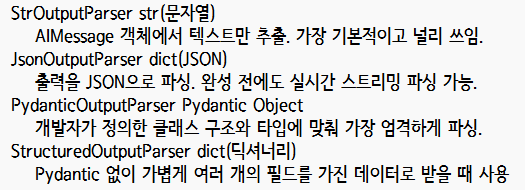

In [ ]:
import os

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 초보자에게 쉽게 설명하는 AI 튜터야."),
    ("human", "{topic}에 대해 5줄 이내로 쉽게 설명해줘."),
])
#system이랑 human이랑 나눠서 하고싶으면 chat을 사용

parser = StrOutputParser()
#OutParser는 여러 종류가 있음

if os.getenv("OPENAI_API_KEY"):
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    basic_llm_chain = prompt | model | parser #이게 하나의 객체를 만드는 것
    # prompt
    # model
    # parser
    answer = basic_llm_chain.invoke({"topic": "LangChain LCEL"})
    print(answer)
else:
    print("OPENAI_API_KEY가 없어 LLM 호출 예제는 건너뜁니다.")

LangChain LCEL은 "Language Chain Event Log"의 약자로, 언어 모델과 관련된 이벤트를 기록하고 관리하는 시스템입니다. 이 시스템은 다양한 언어 처리 작업에서 발생하는 이벤트를 추적하여, 모델의 성능을 분석하고 개선하는 데 도움을 줍니다. LCEL을 사용하면 개발자들이 언어 모델의 행동을 이해하고, 문제를 해결하는 데 필요한 정보를 쉽게 얻을 수 있습니다. 간단히 말해, LCEL은 언어 모델의 활동을 기록하는 일종의 일지입니다.


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 초보자에게 쉽게 설명하는 AI 튜터야."),
    ("human", "{topic}에 대해 5줄 이내로 쉽게 설명해줘."),
])

model = ChatOllama(
    model="exaone3.5",
    temperature=0,
)

parser = StrOutputParser()

basic_chain = prompt | model | parser

answer = basic_chain.invoke({"topic": "LangChain LCEL"})
print(answer)

LangChain LCEL은 **대화형 AI 모델의 성능을 측정하는 표준 지표**야. 

쉽게 말해, **AI가 얼마나 자연스럽고 유용한 대화를 할 수 있는지** 보여주는 거라고 생각하면 돼!

* **정확성**, **유용성**, **자연스러움** 등을 종합적으로 평가해.
* **개발자들이 AI를 개선하는 데 도움**을 주고, **사용자에게 더 나은 경험**을 제공하는 데 기여해.


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field

class Answer(BaseModel):
    topic: str = Field(description="질문 타픽")
    answer: str = Field(description="답변")

parser = JsonOutputParser(pydantic_object=Answer)
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 초보자에게 쉽게 설명하는 AI 튜터야. 다음 요청을 엄격하게 json으로만 답변주세요. {fmt}"),
    ("human", "{topic}에 대해 5줄 이내로 쉽게 설명해줘."),
])

model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)
basic_chain = prompt | model | parser
result = basic_chain.invoke({"topic": "LangChain LCEL", "fmt":parser.get_format_instructions()})
print(type(result))
print(result)

<class 'dict'>
{'description': 'LangChain LCEL은 언어 모델을 사용하여 다양한 작업을 수행할 수 있도록 돕는 프레임워크입니다. 이 프레임워크는 언어 모델을 쉽게 연결하고 조작할 수 있는 도구를 제공합니다. 사용자는 자연어 처리, 데이터 검색, 대화형 응답 생성 등 다양한 기능을 활용할 수 있습니다. LCEL은 개발자들이 복잡한 작업을 간단하게 구현할 수 있도록 설계되었습니다. 이를 통해 더 효율적이고 창의적인 애플리케이션을 만들 수 있습니다.'}


In [19]:
def clean_output(text: str) -> str:
    while "\n\n\n" in text:
        text = text.replace("\n\n\n", "\n\n")
    return text.strip()

cleaned_chain = basic_chain | RunnableLambda(clean_output)
result = basic_chain.invoke({"topic": "LangChain LCEL"})
print(type(result))
print(result)

<class 'dict'>
{'description': 'LangChain LCEL은 언어 모델을 사용하여 다양한 작업을 수행하는 프레임워크입니다. 이 프레임워크는 자연어 처리(NLP) 작업을 쉽게 구현할 수 있도록 도와줍니다. LCEL은 여러 데이터 소스와 통합하여 정보를 처리하고, 사용자와 상호작용할 수 있는 기능을 제공합니다. 이를 통해 개발자들은 복잡한 언어 모델을 간단하게 사용할 수 있습니다. LangChain은 특히 대화형 애플리케이션에 유용합니다.'}


위 prompt는 `{topic}`을 요구하므로 입력은 아래처럼 dict 형태여야 한다.

```python
{"topic": "LangChain LCEL"}
```

### 4. 입력 shape 실수 확인하기

LCEL에서 제일 많이 헷갈리는 부분은 문법보다 **입력과 출력의 모양**이다.

아래 prompt는 `{name}`이라는 변수를 필요로 한다.

In [32]:
name_prompt = ChatPromptTemplate.from_template("안녕하세요, {name}님! 오늘 배울 주제는 LCEL입니다.")

# 올바른 입력
print(name_prompt.invoke({"name": "둘리"}))

messages=[HumanMessage(content='안녕하세요, 둘리님! 오늘 배울 주제는 LCEL입니다.', additional_kwargs={}, response_metadata={})]


```python
prompt = ChatPromptTemplate.from_template("안녕 {name}")
```
이 prompt는 아래 입력을 기대한다.
```python
{"name": "둘리"}
```
LCEL 체인을 만들 때는 각 단계의 입력과 출력이 서로 맞는지 항상 확인해야 한다.

### 5. Dict / RunnableParallel: 여러 값을 동시에 만들기

LCEL에서는 여러 Runnable을 병렬로 실행해서 dict 형태로 합칠 수 있다.

예를 들어 같은 입력 문자열에서

- 원본 문자열
- 대문자 문자열
- 문자열 길이

를 동시에 만들 수 있다.

In [21]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

parallel_chain = RunnableParallel({
    "original": RunnablePassthrough(),
    "upper": RunnableLambda(lambda x: x.upper()),
    "length": RunnableLambda(lambda x: len(x)),
})

parallel_result = parallel_chain.invoke("  hello lcel  ")
parallel_result

{'original': '  hello lcel  ', 'upper': '  HELLO LCEL  ', 'length': 14}

`RunnablePassthrough()`는 입력을 그대로 넘겨주는 Runnable.
RAG 예제에서 아래와 같은 구조를 많이 보게 되는데
```python
{
    "context": retriever,
    "question": RunnablePassthrough()
}
```
의미는 다음과 같다.
```text
같은 입력 질문을 받아서
- context는 retriever로 만들고
- question은 원본 질문을 그대로 유지한다
```

### 6. Fake Retriever로 RAG 구조 이해하기

이번 단계에서는 실제 벡터 DB 없이, RAG 파이프라인의 구조만 가볍게 흉내 내어 테스트해 본다.

RAG의 기본 흐름은 다음과 같다.

```text
질문
→ 관련 문서 검색
→ 검색 문서를 context에 넣음
→ 질문과 context를 함께 LLM에 전달
→ 답변 생성
```

In [ ]:
#백터db는 없이 rag파이프라인만 가볍게 흉내내어 실행해본다
#컨텍스트에 담겨진 내용을 전달하여 답변함

docs = [
    "LCEL은 LangChain 컴포넌트를 파이프처럼 연결하는 문법이다.",
    "Runnable은 invoke, batch, stream 같은 공통 실행 인터페이스를 가진다.",
    "RAG는 검색된 문서를 context로 넣고 질문에 답하는 방식이다.",
    "RunnablePassthrough는 입력을 그대로 넘기거나 assign으로 값을 추가할 때 유용하다.",
]


def fake_retriever(question: str):
    """아주 단순한 예제용 검색기입니다."""
    keywords = ["LCEL", "Runnable", "RAG", "context", "stream", "batch", "invoke"]
    matched = []

    for doc in docs:
        if any(keyword.lower() in question.lower() or keyword.lower() in doc.lower() for keyword in keywords):
            #질문에 들어간 키워드와 문서가 관련 있어 보이면 추가
            #하나라도 존재하면 넣게다는 의미
            #없는 키워드를 넣으면 비어있게 됨
            if any(keyword.lower() in question.lower() and keyword.lower() in doc.lower() for keyword in keywords):
                matched.append(doc)

    return matched or docs[:1]

def format_docs(retrieved_docs):
    return "\n".join(f"- {doc}" for doc in retrieved_docs)


retriever_chain = RunnableLambda(fake_retriever) | RunnableLambda(format_docs)

rag_input_chain = RunnableParallel({
    "context": retriever_chain,
    "question": RunnablePassthrough(),
})

rag_input = rag_input_chain.invoke("LCEL과 Runnable은 무슨 관계야?")
print(rag_input)

{'context': '- LCEL은 LangChain 컴포넌트를 파이프처럼 연결하는 문법이다.\n- Runnable은 invoke, batch, stream 같은 공통 실행 인터페이스를 가진다.\n- RunnablePassthrough는 입력을 그대로 넘기거나 assign으로 값을 추가할 때 유용하다.', 'question': 'LCEL과 Runnable은 무슨 관계야?'}


질문 하나를 넣었는데, 아래 형태의 dict가 만들어졌습니다.

```python
{
    "context": "검색된 문서들...",
    "question": "원본 질문..."
}
```
이제 이 dict(전처리 체인)를 prompt에 넣으면 RAG 체인이 된다.

In [23]:
rag_prompt = ChatPromptTemplate.from_template("""
다음 context만 참고해서 질문에 답해줘.

[context]
{context}

[question]
{question}
""")#위에 내용이 그대로 모델에 넣게 됨

if os.getenv("OPENAI_API_KEY"):
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    rag_chain = rag_input_chain | rag_prompt | model | StrOutputParser()

    answer = rag_chain.invoke("LCEL과 Runnable은 무슨 관계야?")
    print(answer)
else:
    print("OPENAI_API_KEY가 없어 RAG LLM 호출 예제는 건너뜁니다.")
    print("대신 prompt에 들어갈 입력만 확인합니다:\n")
    print(rag_input_chain.invoke("LCEL과 Runnable은 무슨 관계야?"))

LCEL은 LangChain 컴포넌트를 파이프처럼 연결하는 문법으로, Runnable은 이러한 컴포넌트들이 공통적으로 가지는 실행 인터페이스를 제공하는 요소입니다. 즉, LCEL을 사용하여 Runnable 컴포넌트들을 연결하고, 이들을 통해 데이터를 처리하거나 전달하는 방식으로 활용할 수 있습니다. 따라서 LCEL은 Runnable을 연결하는 방법론이라고 할 수 있습니다.



RAG에서 가장 자주 쓰는 LCEL 패턴은 결국 아래입니다.

```python
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | model
    | parser
)
```

이 패턴만 익숙해져도 LangChain RAG 코드의 상당 부분을 읽을 수 있다.

### 7. RunnablePassthrough.assign: 기존 입력에 값 추가하기

`assign`은 기존 dict 입력에 새로운 key를 추가할 때 사용한다.

예를 들어 문장과 함께 문장 길이를 계산해서 넣어보겠습니다.

In [24]:
assign_chain = RunnablePassthrough.assign(
    length=lambda x: len(x["text"]),
    preview=lambda x: x["text"][:10] + "...",
)

assign_result = assign_chain.invoke({
    "text": "LangChain LCEL은 체인을 조립하기 쉽게 해준다."
})

assign_result

{'text': 'LangChain LCEL은 체인을 조립하기 쉽게 해준다.',
 'length': 32,
 'preview': 'LangChain ...'}

처음 입력은 아래 형태였다.

```python
{"text": "LangChain LCEL은 체인을 조립하기 쉽게 해준다."}
```

`assign` 이후에는 아래처럼 key가 추가된다.

```python
{
    "text": "...",
    "length": 31,
    "preview": "LangChain ..."
}
```

In [ ]:
analysis_prompt = ChatPromptTemplate.from_template("""
다음 문장을 분석해줘.

문장: {text}
문장 길이: {length}
미리보기: {preview}

간단히 평가해줘.
""")

if os.getenv("OPENAI_API_KEY"):
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    analysis_chain = assign_chain | analysis_prompt | model | StrOutputParser()

    result = analysis_chain.invoke({
        "text": "LangChain LCEL은 체인을 조립하기 쉽게 해준다."
    })

    print(result)
else:
    print("OPENAI_API_KEY가 없어 LLM 호출 예제는 건너뜁니다.")
    print(assign_chain.invoke({"text": "LangChain LCEL은 체인을 조립하기 쉽게 해준다."}))

### 8. RunnableBranch: 조건에 따라 다른 체인 실행하기

질문 유형에 따라 다른 처리 흐름을 수행할 수도 있다.

예를 들어:

```text
코드 질문 → 코드 리뷰어 스타일
클라우드 질문 → 클라우드 엔지니어 스타일
그 외 질문 → 일반 설명 스타일
```

처럼 나눌 수 있다.

In [ ]:
from langchain_core.runnables import RunnableBranch, RunnableLambda

code_chain = RunnableLambda(lambda x: f"[코드 리뷰어 모드] 질문: {x['question']}")
cloud_chain = RunnableLambda(lambda x: f"[클라우드 엔지니어 모드] 질문: {x['question']}")
general_chain = RunnableLambda(lambda x: f"[일반 설명 모드] 질문: {x['question']}")

router_chain = RunnableBranch(
    (lambda x: "코드" in x["question"] or "파이썬" in x["question"], code_chain), # 질문에 따라 어떤 걸 실행할지 달라짐
    (lambda x: "쿠버네티스" in x["question"] or "클라우드" in x["question"], cloud_chain),
    general_chain,
)

questions = [
    {"question": "파이썬 코드에서 에러가 나."},
    {"question": "쿠버네티스 Pod가 Pending이야."},
    {"question": "LCEL을 쉽게 설명해줘."},
]

for q in questions:
    print(router_chain.invoke(q))

    

[코드 리뷰어 모드] 질문: 파이썬 코드에서 에러가 나.
[클라우드 엔지니어 모드] 질문: 쿠버네티스 Pod가 Pending이야.
[일반 설명 모드] 질문: LCEL을 쉽게 설명해줘.


LLM을 붙이면 각 분기마다 다른 프롬프트를 사용할 수 있다.

In [26]:
if os.getenv("OPENAI_API_KEY"):
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    parser = StrOutputParser()

    code_llm_chain = (
        ChatPromptTemplate.from_template(
            "너는 코드 리뷰어야. 다음 질문에 코드 중심으로 답해줘:\n{question}"
        )
        | model
        | parser
    )

    cloud_llm_chain = (
        ChatPromptTemplate.from_template(
            "너는 클라우드 엔지니어야. 다음 질문에 인프라 관점으로 답해줘:\n{question}"
        )
        | model
        | parser
    )

    general_llm_chain = (
        ChatPromptTemplate.from_template(
            "다음 질문에 초보자도 이해하기 쉽게 답해줘:\n{question}"
        )
        | model
        | parser
    )

    llm_router_chain = RunnableBranch(
        (lambda x: "코드" in x["question"] or "파이썬" in x["question"], code_llm_chain),
        (lambda x: "쿠버네티스" in x["question"] or "클라우드" in x["question"], cloud_llm_chain),
        general_llm_chain,
    )

    print(llm_router_chain.invoke({
        "question": "쿠버네티스 Pod가 계속 Pending일 때 어디를 봐야 해?"
    }))
else:
    print("OPENAI_API_KEY가 없어 LLM 라우터 예제는 건너뜁니다.")

쿠버네티스에서 Pod가 Pending 상태에 있는 경우, 여러 가지 원인이 있을 수 있습니다. 인프라 관점에서 확인해야 할 주요 사항은 다음과 같습니다:

1. **리소스 할당**:
   - Pod가 요청한 CPU와 메모리 리소스가 클러스터의 노드에서 사용 가능한지 확인합니다. `kubectl describe pod <pod-name>` 명령어를 사용하여 Pod의 리소스 요청을 확인하고, 클러스터의 노드에서 해당 리소스가 충분한지 점검합니다.

2. **노드의 상태**:
   - 클러스터의 노드가 정상적으로 작동하고 있는지 확인합니다. `kubectl get nodes` 명령어로 노드의 상태를 확인하고, Ready 상태인지 확인합니다. 노드가 NotReady 상태라면, 해당 노드에서 Pod를 스케줄할 수 없습니다.

3. **스케줄러의 문제**:
   - 쿠버네티스 스케줄러가 Pod를 적절한 노드에 할당하지 못하는 경우가 있습니다. 스케줄러의 로그를 확인하여 오류 메시지가 있는지 점검합니다.

4. **Taints와 Tolerations**:
   - 노드에 Taint가 설정되어 있는 경우, Pod가 해당 노드에 스케줄되기 위해서는 Toleration이 필요합니다. Pod의 정의에서 Toleration이 설정되어 있는지 확인합니다.

5. **Affinity와 Anti-affinity 규칙**:
   - Pod에 설정된 Affinity 또는 Anti-affinity 규칙이 다른 Pod와의 배치에 영향을 줄 수 있습니다. 이러한 규칙이 Pod의 스케줄링을 방해하고 있는지 확인합니다.

6. **Persistent Volume Claims (PVC)**:
   - Pod가 Persistent Volume을 사용하려고 하는 경우, PVC가 바인딩되지 않았거나 사용할 수 있는 PV가 없는지 확인합니다. PVC의 상태를 확인하고, 필요한 PV가 존재하는지 점검합니다.

7. **네트워크 정책**:
   - 네트워크 정책이 Pod의 통신을 제한하고 있는지 확인합니다. 네

- RunnableBranch는if-else 조건문(분기문)을 LCEL 체인 형태로 만들어 놓은 컴포넌트이다.
- **A 조건일 때는 A 체인으로, B 조건일 때는 B 체인으로**

### 9. 스트리밍 예제

LLM 체인에서 `stream()`을 사용하면 답변을 조각 단위로 받을 수 있다.

터미널이나 웹앱에서 실시간으로 답변이 생성되는 것처럼 보여주고 싶을 때 유용하다.

In [27]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

stream_chain = (
    ChatPromptTemplate.from_template("{topic}에 대해 아주 쉽게 설명해줘.")
    | model
    | StrOutputParser()
)

In [ ]:

for chunk in stream_chain.stream({"topic": "LCEL stream"}): #와다다다다 출력
    print(chunk, end="", flush=True)

LCEL(stream)은 "Low-Cost Energy Loss"의 약자로, 주로 에너지 효율성과 관련된 개념입니다. 쉽게 말해, LCEL stream은 에너지를 사용하는 과정에서 발생하는 불필요한 에너지 손실을 줄이기 위한 방법이나 기술을 의미합니다.

예를 들어, 우리가 전기를 사용할 때, 전기 기기가 효율적으로 작동하지 않으면 에너지가 낭비될 수 있습니다. LCEL stream은 이러한 낭비를 최소화하고, 더 적은 에너지를 사용하면서도 같은 결과를 얻을 수 있도록 도와줍니다.

결국, LCEL stream은 에너지를 절약하고, 비용을 줄이며, 환경에도 긍정적인 영향을 미치는 방법이라고 할 수 있습니다.

In [ ]:
result = stream_chain.invoke({"topic": "LCEL stream"}) # 바로 띡 출력
print(result)

LCEL(stream)은 "Low-Cost Energy Loss"의 약자로, 주로 에너지 효율성과 관련된 개념입니다. 쉽게 말해, LCEL stream은 에너지를 사용하는 과정에서 발생하는 불필요한 에너지 손실을 줄이기 위한 방법이나 기술을 의미합니다.

예를 들어, 우리가 전기를 사용할 때, 전구나 기계가 에너지를 효율적으로 사용하지 않으면 그만큼 에너지가 낭비됩니다. LCEL stream은 이러한 낭비를 최소화하고, 더 적은 에너지로 같은 결과를 얻을 수 있도록 도와주는 시스템이나 전략을 포함합니다.

결국, LCEL stream은 에너지를 절약하고, 비용을 줄이며, 환경에도 긍정적인 영향을 미치는 방법이라고 할 수 있습니다.


### 10. 배치 실행 예제

`batch()`는 여러 입력을 한 번에 처리할 때 사용한다.

LLM API를 여러 번 호출해야 하는 경우, 반복문보다 깔끔하게 작성할 수 있다.

In [ ]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
#병렬처리를 하고 싶다면 batch를 사용해도 됨. 멀티스레드를 알아서 구축해줌

explain_chain = (
    ChatPromptTemplate.from_template("{keyword}를 한 문장으로 쉽게 설명해줘.")
    | model
    | StrOutputParser()
)

batch_inputs = [
    {"keyword": "LCEL"},
    {"keyword": "Runnable"},
    {"keyword": "RAG"},
]

batch_results = explain_chain.batch(batch_inputs)#키워드 정보를 담고있는 리스트를 아규먼트로 줌, 순서대로 처리하는게 아니라 병렬처리됨
print(type(batch_inputs))#타입체크를 직접해봐도 됨 list로 출력됨

for keyword, result in zip(batch_inputs, batch_results):
    print(f"[{keyword['keyword']}]")
    print(result)
    print()

<class 'list'>
[LCEL]
LCEL은 "Learning-Centered Experiential Learning"의 약자로, 학습자가 경험을 통해 직접 배우고 성장할 수 있도록 돕는 교육 방법입니다.

[Runnable]
Runnable은 Java에서 스레드를 실행할 수 있도록 하는 인터페이스로, run() 메서드를 구현하여 실행할 작업을 정의합니다.

[RAG]
RAG는 "Retrieval-Augmented Generation"의 약자로, 정보를 검색하여 그 결과를 바탕으로 텍스트를 생성하는 AI 기술입니다.



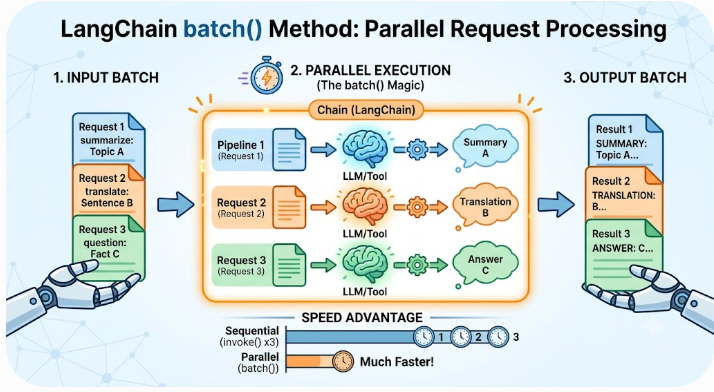

### 11. 최종 미니 프로젝트: LCEL 기반 간단한 문서 요약기

입력으로 문서를 넣으면:

1. 문서 길이를 계산하고
2. 미리보기를 만들고
3. LLM에게 요약을 요청한다.

In [ ]:
summary_preprocess_chain = RunnablePassthrough.assign(
    length=lambda x: len(x["document"]),
    preview=lambda x: x["document"][:80] + "..." if len(x["document"]) > 80 else x["document"],
)

summary_prompt = ChatPromptTemplate.from_template("""
다음 문서를 요약해줘.

문서 길이: {length}
문서 미리보기: {preview}

[문서]
{document}

요구사항:
- 핵심 내용 3개 bullet로 정리
- 마지막에 한 줄 결론 추가
""")

sample_document = """
LCEL은 LangChain Expression Language의 약자이며, LangChain에서 체인을 선언적으로 구성하기 위한 방식이다.
PromptTemplate, ChatModel, OutputParser, Retriever, RunnableLambda 같은 구성 요소를 파이프 연산자(|)로 연결할 수 있다.
LCEL을 사용하면 invoke, batch, stream 같은 공통 실행 인터페이스를 통해 단일 실행, 배치 실행, 스트리밍 실행을 일관되게 다룰 수 있다.
또한 RunnablePassthrough, RunnableParallel, RunnableBranch 등을 활용하면 입력 유지, 병렬 구성, 조건 분기 같은 패턴도 표현할 수 있다.
"""
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

summary_chain = summary_preprocess_chain | summary_prompt | model | StrOutputParser()
                        # 전처리 체인(입력 준비 단계) -> 프롬프트 -> 모델 -> 출력 파서

summary = summary_chain.invoke({"document": sample_document})
print(summary)


### 12. LCEL 핵심 패턴 요약

자주 쓰는 패턴만 다시 정리하면 다음과 같다.

#### 1. 기본 LLM 체인

```python
chain = prompt | model | parser
```

#### 2. 전처리 후 LLM 호출

```python
chain = preprocess | prompt | model | parser
```

#### 3. RAG

```python
chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | model
    | parser
)
```

#### 4. 기존 입력에 값 추가

```python
chain = RunnablePassthrough.assign(
    new_key=lambda x: ...
)
```

#### 5. 조건 분기

```python
chain = RunnableBranch(
    (condition_a, chain_a),
    (condition_b, chain_b),
    default_chain,
)
```

LCEL을 공부할 때는 항상 다음 질문을 하면 된다.

```text
이 단계의 입력 shape은 무엇인가?
이 단계의 출력 shape은 무엇인가?
다음 단계가 그 출력을 받을 수 있는가?
```

이 감각이 잡히면 LangChain 코드를 훨씬 편하게 읽고 수정할 수 있다.